In [1]:
# --- Output-Structure Constraint: Ordinal Consistency ---
# Reframe Wisconsin as a 3-class ordinal problem: Low / Medium / High risk
# Then enforce that the model's output probabilities respect the ordering

import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:

data = load_breast_cancer()
X = data.data
y_binary = data.target  # 1=benign, 0=malignant

# Create a 3-class ordinal target based on "worst radius" as a risk proxy:
# Low risk: benign AND worst radius in bottom tertile
# Medium risk: benign AND worst radius in top two tertiles, OR malignant AND bottom tertile
# High risk: malignant AND worst radius in top two tertiles
worst_radius = X[:, list(data.feature_names).index('worst radius')]
radius_threshold = np.percentile(worst_radius, 33)

y_ordinal = np.where(
    (y_binary == 1) & (worst_radius <= radius_threshold), 0,  # low risk
    np.where(
        (y_binary == 0) & (worst_radius > radius_threshold), 2,  # high risk
        1  # medium risk
    )
)

X_train, X_test, y_train, y_test = train_test_split(X, y_ordinal, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
X_test_s = torch.tensor(scaler.transform(X_test), dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)


In [3]:

# 3-class MLP
class OrdinalMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 3),  # 3 classes: low, medium, high
        )
    def forward(self, x):
        return self.net(x)



In [ ]:
# --- The output-structure constraint ---
# Ordinal consistency: if the model's argmax is "low risk" (class 0),
# then P(low) should be > P(medium) > P(high).
# More generally: penalize any violation of the ordering P(class k) > P(class k+1)
# for all classes below the predicted class.

def ordinal_consistency_loss(logits, lambda_ordinal=1.0):
    """
    Penalize cases where the model's softmax probabilities violate ordinal ordering.
    For a 3-class ordinal problem (low < medium < high risk):
    - The cumulative probability P(risk >= k) should decrease as k increases
    - Equivalently: penalize when P(class j) > P(class i) for j > i, 
      among classes that should both be "unlikely" given the prediction
    """
    probs = torch.softmax(logits, dim=1)  # shape: (batch, 3)
    
    # Penalize when P(high) > P(medium) for samples predicted as low risk
    # AND when P(low) > P(medium) for samples predicted as high risk
    
    predicted = torch.argmax(probs, dim=1)
    penalty = torch.tensor(0.0)
    
    # For samples predicted as low risk (class 0):
    # P(high) should be < P(medium) should be < P(low)
    low_mask = predicted == 0
    if low_mask.sum() > 0:
        p = probs[low_mask]
        # Penalize if P(high) > P(medium) — the ordering is "backwards"
        penalty = penalty + torch.relu(p[:, 2] - p[:, 1]).mean()
    
    # For samples predicted as high risk (class 2):
    # P(low) should be < P(medium) should be < P(high)
    high_mask = predicted == 2
    if high_mask.sum() > 0:
        p = probs[high_mask]
        # Penalize if P(low) > P(medium) — the ordering is "backwards"
        penalty = penalty + torch.relu(p[:, 0] - p[:, 1]).mean()
    
    return lambda_ordinal * penalty


In [5]:

# --- Train with and without ordinal constraint ---
def train_ordinal_model(use_constraint=False, epochs=150):
    model = OrdinalMLP(X_train_s.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    ce_loss = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_s)
        loss = ce_loss(logits, y_train_t)
        if use_constraint:
            loss = loss + ordinal_consistency_loss(logits, lambda_ordinal=1.0)
        loss.backward()
        optimizer.step()
    return model



In [6]:
model_uc = train_ordinal_model(use_constraint=False)
model_c = train_ordinal_model(use_constraint=True)

# Compare: do the constrained model's probability distributions look "cleaner"?
for name, model in [("Unconstrained", model_uc), ("Constrained", model_c)]:
    model.eval()
    with torch.no_grad():
        logits = model(X_test_s)
        probs = torch.softmax(logits, dim=1).numpy()
        preds = np.argmax(probs, axis=1)
    
    # Check ordinal violations: how often is P(high) > P(medium) when predicted low?
    low_pred = preds == 0
    if low_pred.sum() > 0:
        violations = (probs[low_pred, 2] > probs[low_pred, 1]).mean()
        print(f"{name}: Among low-risk predictions, "
              f"{violations:.1%} have P(high) > P(medium) [ordinal violation]")
    
    acc = (preds == y_test).mean()
    print(f"{name}: Accuracy = {acc:.3f}\n")



Unconstrained: Among low-risk predictions, 0.0% have P(high) > P(medium) [ordinal violation]
Unconstrained: Accuracy = 0.921

Constrained: Among low-risk predictions, 0.0% have P(high) > P(medium) [ordinal violation]
Constrained: Accuracy = 0.904



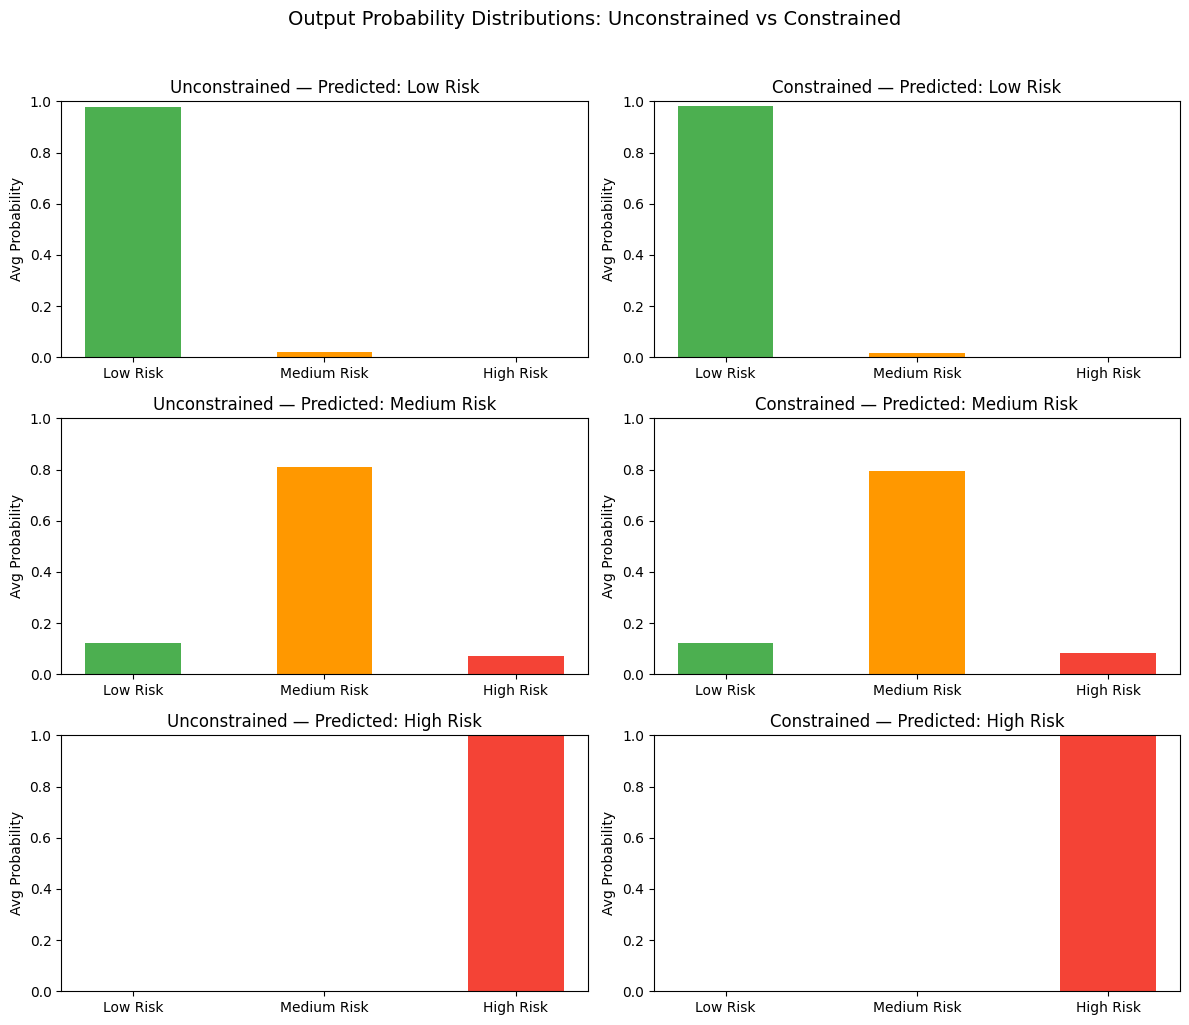

Ordinal Consistency Analysis

--- Unconstrained Model ---
  Low-risk preds (n=40):
    P(high) > P(med) violations: 0 (0.0%)
    P(med) > P(low) violations:  0 (0.0%)
  Medium-risk preds (n=32):
    P(low) > P(med) violations:  0 (0.0%)
    P(high) > P(med) violations: 0 (0.0%)
  High-risk preds (n=42):
    P(low) > P(med) violations:  0 (0.0%)
    P(med) > P(high) violations: 0 (0.0%)

  Overall violation rate: 0/228 (0.0%)

--- Constrained Model ---
  Low-risk preds (n=41):
    P(high) > P(med) violations: 0 (0.0%)
    P(med) > P(low) violations:  0 (0.0%)
  Medium-risk preds (n=32):
    P(low) > P(med) violations:  0 (0.0%)
    P(high) > P(med) violations: 0 (0.0%)
  High-risk preds (n=41):
    P(low) > P(med) violations:  0 (0.0%)
    P(med) > P(high) violations: 0 (0.0%)

  Overall violation rate: 0/228 (0.0%)

Sharpness Analysis (entropy of output distributions)

Unconstrained avg entropy: 0.2132
Constrained avg entropy:   0.2253

(Lower entropy = sharper, more confident predicti

In [ ]:
import matplotlib.pyplot as plt

# --- 1: Visualize probability distributions for test samples ---

model_uc.eval()
model_c.eval()

with torch.no_grad():
    logits_uc = model_uc(X_test_s)
    probs_uc = torch.softmax(logits_uc, dim=1).numpy()
    preds_uc = np.argmax(probs_uc, axis=1)

    logits_c = model_c(X_test_s)
    probs_c = torch.softmax(logits_c, dim=1).numpy()
    preds_c = np.argmax(probs_c, axis=1)

# Select up to 3 samples per predicted class for each model
class_names = ['Low Risk', 'Medium Risk', 'High Risk']
sample_indices = {}
for cls in range(3):
    mask = np.where(preds_uc == cls)[0]
    sample_indices[cls] = mask[:3] if len(mask) >= 3 else mask

# Plot side-by-side: unconstrained vs constrained for each sample
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle('Output Probability Distributions: Unconstrained vs Constrained', fontsize=14, y=1.02)

x_pos = np.arange(3)
bar_width = 0.5

for row, cls in enumerate(range(3)):
    indices = sample_indices[cls]
    if len(indices) == 0:
        axes[row, 0].text(0.5, 0.5, 'No samples', ha='center', va='center')
        axes[row, 1].text(0.5, 0.5, 'No samples', ha='center', va='center')
        continue

    # Average across selected samples for a cleaner view
    avg_uc = probs_uc[indices].mean(axis=0)
    avg_c = probs_c[indices].mean(axis=0)

    colors = ['#4CAF50', '#FF9800', '#F44336']

    axes[row, 0].bar(x_pos, avg_uc, bar_width, color=colors)
    axes[row, 0].set_title(f'Unconstrained — Predicted: {class_names[cls]}')
    axes[row, 0].set_xticks(x_pos)
    axes[row, 0].set_xticklabels(class_names)
    axes[row, 0].set_ylabel('Avg Probability')
    axes[row, 0].set_ylim(0, 1)

    axes[row, 1].bar(x_pos, avg_c, bar_width, color=colors)
    axes[row, 1].set_title(f'Constrained — Predicted: {class_names[cls]}')
    axes[row, 1].set_xticks(x_pos)
    axes[row, 1].set_xticklabels(class_names)
    axes[row, 1].set_ylabel('Avg Probability')
    axes[row, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


# --- 2: Quantify ordinal consistency across ALL predicted classes ---

print("=" * 70)
print("Ordinal Consistency Analysis")
print("=" * 70)

for name, probs, preds in [("Unconstrained", probs_uc, preds_uc),
                             ("Constrained", probs_c, preds_c)]:
    print(f"\n--- {name} Model ---")
    total_violations = 0
    total_samples = 0

    # For predicted low risk (class 0): P(low) > P(med) > P(high) expected
    low_mask = preds == 0
    if low_mask.sum() > 0:
        p = probs[low_mask]
        v1 = (p[:, 2] > p[:, 1]).sum()  # P(high) > P(med) violation
        v2 = (p[:, 1] > p[:, 0]).sum()  # P(med) > P(low) violation
        total = low_mask.sum()
        total_violations += v1 + v2
        total_samples += total * 2  # 2 ordering checks per sample
        print(f"  Low-risk preds (n={total}):")
        print(f"    P(high) > P(med) violations: {v1} ({v1/total:.1%})")
        print(f"    P(med) > P(low) violations:  {v2} ({v2/total:.1%})")

    # For predicted medium risk (class 1): P(med) > P(low) and P(med) > P(high) expected
    med_mask = preds == 1
    if med_mask.sum() > 0:
        p = probs[med_mask]
        v1 = (p[:, 0] > p[:, 1]).sum()  # P(low) > P(med) violation
        v2 = (p[:, 2] > p[:, 1]).sum()  # P(high) > P(med) violation
        total = med_mask.sum()
        total_violations += v1 + v2
        total_samples += total * 2
        print(f"  Medium-risk preds (n={total}):")
        print(f"    P(low) > P(med) violations:  {v1} ({v1/total:.1%})")
        print(f"    P(high) > P(med) violations: {v2} ({v2/total:.1%})")

    # For predicted high risk (class 2): P(high) > P(med) > P(low) expected
    high_mask = preds == 2
    if high_mask.sum() > 0:
        p = probs[high_mask]
        v1 = (p[:, 0] > p[:, 1]).sum()  # P(low) > P(med) violation
        v2 = (p[:, 1] > p[:, 2]).sum()  # P(med) > P(high) violation
        total = high_mask.sum()
        total_violations += v1 + v2
        total_samples += total * 2
        print(f"  High-risk preds (n={total}):")
        print(f"    P(low) > P(med) violations:  {v1} ({v1/total:.1%})")
        print(f"    P(med) > P(high) violations: {v2} ({v2/total:.1%})")

    rate = total_violations / total_samples if total_samples > 0 else 0
    print(f"\n  Overall violation rate: {total_violations}/{total_samples} ({rate:.1%})")


# --- Sharpness comparison ---
print("\n" + "=" * 70)
print("Sharpness Analysis (entropy of output distributions)")
print("=" * 70)

def avg_entropy(probs_array):
    """Lower entropy = sharper, more confident predictions."""
    eps = 1e-10
    entropy = -np.sum(probs_array * np.log(probs_array + eps), axis=1)
    return entropy.mean()

print(f"\nUnconstrained avg entropy: {avg_entropy(probs_uc):.4f}")
print(f"Constrained avg entropy:   {avg_entropy(probs_c):.4f}")
print(f"\n(Lower entropy = sharper, more confident predictions)")